# Comprehensive TikTok Data Collection for Computational Social Science

**ICWSM 2026 Tutorial**
Gayoung Jeon, Cameron Moy, Deen Freelon
Annenberg School for Communication, University of Pennsylvania

---

This notebook is the hands-on companion to our ICWSM 2026 tutorial. It introduces TikTok data collection through three different tools — the official **TikTok Research API**, **Apify** (a commercial cloud scraping platform), and **Pyktok** (an open-source browser-based scraper shipped in this repository). The three tools differ substantially in cost, access requirements, and the data they return; our stress-testing research finds they frequently produce strikingly different results even when given identical queries.

**Pyktok** is currently undergoing a full revision that adds support for additional endpoints and multiple collection modes, in line with our broader commitment to replicable and transparent data collection for scientific research. This tutorial demonstrates three of its endpoints (Hashtag, Keyword, Sound). The code is provided **as-is** and you use it at your own risk. We are actively working to merge this functionality back into the public [Pyktok](https://github.com/dfreelon/pyktok) release — coming soon.

You do not need to use all three tools. Each section is self-contained — follow whichever apply to your setup.

**Sections:**
- [1. Setup](#1.-Setup)
- [2-1. TikTok Research API](#2-1.-TikTok-Research-API) — User, Keyword, Hashtag, Comments
- [2-2. Apify](#2-2.-Apify) — User, Keyword, Hashtag, Comments, Related Videos
- [2-3. Pyktok ](#2-3.-Pyktok) — Hashtag, Keyword, Sound


## Tools at a Glance

| | Research API | Apify | pyktok_2026 |
|---|---|---|---|
| **Access** | Academic application (takes weeks) | Free tier (~$5 credit) | Free, open source |
| **Cost** | Free | ~$0.25 - $1.00 per 1,000 results | Free |
| **Endpoints** | User, Keyword, Hashtag, Comments | User, Keyword, Hashtag, Comments, Related | Hashtag, Keyword, Sound |
| **Data source** | Back-end API | Front-end cloud scrape | Front-end browser scrape |
| **Daily limits** | 1,000 API calls/day | Credit-based | TikTok rate limits apply |
| **Auth required** | Yes (OAuth token) | API token | None |


---
## 1. Setup

Install everything before collecting. Run these cells once at the start
of each session.


In [12]:
# TikTok Research API wrapper + utilities
!pip install -q TikTokResearchApi python-dotenv pandas requests tqdm

In [13]:
# Apify client (used in section 2-2)
!pip install -q apify-client


In [14]:
# pyktok_2026 — the open-source scraper we ship in this repo.
# Installs the local copy in editable mode + Playwright's Chromium binary.
!pip install -q -e .
!playwright install chromium


### 1.1 Credentials

Create a file called `credential.env` in the same directory as this notebook
(a `credential.env.example` is included in the repo as a template):

```
# TikTok Research API
CLIENT_KEY=your_client_key_here
CLIENT_SECRET=your_client_secret_here

# Apify
APIFY_API_TOKEN=your_apify_token_here
```

Where to find these:
- **TikTok API credentials:** [developers.tiktok.com/products/research-api](https://developers.tiktok.com/products/research-api/). Apply at least a month before your project; review takes time.
- **Apify token:** apify.com -> Settings -> Integrations -> API Token.
- **pyktok_2026:** no credentials needed. Section 2-3 uses only public no-login endpoints.

> Do not commit `credential.env`. It is already listed in `.gitignore`.


In [15]:
# Verify your credentials loaded correctly
import os
from dotenv import load_dotenv

load_dotenv("credential.env", override=True)

api_key   = os.getenv("CLIENT_KEY")
apify_tok = os.getenv("APIFY_API_TOKEN")

print("Research API credentials:", "loaded" if api_key   else "MISSING - check credential.env (only needed for section 2-1)")
print("Apify token:             ", "loaded" if apify_tok else "MISSING - check credential.env (only needed for section 2-2)")
print("pyktok_2026:              no credentials needed (section 2-3)")


Research API credentials: loaded
Apify token:              loaded
pyktok_2026:              no credentials needed (section 2-3)


---
## 2-1. TikTok Research API

The Research API is TikTok's official data access program for academic researchers. Because it queries the back-end directly, it bypasses the recommendation algorithm—you're not getting "what TikTok would show a user," you're asking the database directly. That's valuable for some research questions and less useful for others.

You need an approved developer account to use it. Once approved, TikTok gives you a `client_key` and `client_secret`, which you exchange for a short-lived OAuth token. Tokens expire every **2 hours**, so we'll set up automatic renewal.

### API Quota Limits

TikTok enforces a **hard limit of 1,000 API calls per day**, shared across all endpoints. Here's what that means in practice:

| Endpoint | Supported Queries | Max Results per Call | Daily Call Budget | Max Results/Day |
|---|---|---|---|---|
| `/video/query/` | Username | 100 videos | shared 1,000 calls | ~100,000 |
| `/video/query/` | Keyword | 100 videos | shared 1,000 calls | ~100,000 |
| `/video/query/` | Hashtag | 100 videos | shared 1,000 calls | ~100,000 |
| `/comment/list/` | Video ID | 100 comments | shared 1,000 calls | ~100,000 |

**Things to watch for:**
- The 1,000 calls/day is a **shared pool** across all endpoints. Spend 500 on keywords, you only have 500 left for everything else that day.
- The API tends to surface recent and popular content. Running the same query twice may not return the same videos.
- Some queries return fewer results than the quota technically allows — this is an undocumented behavior we encountered repeatedly in stress testing.
- Always validate that returned videos are still accessible on TikTok at the time of collection.

### Getting Started: Simple Setup

For the tutorial, we keep this short. Pass your credentials to `TikTokResearchAPI` and you get back a client that handles authentication internally. That's it — no token management needed for a session under two hours.

In [16]:
import os
import pandas as pd
from datetime import datetime, timezone, timedelta
from dotenv import load_dotenv
from tiktok_research_api import *

load_dotenv("credential.env", override=True)

# Create the API client — the library fetches and caches the OAuth token internally
api = TikTokResearchAPI(
    client_key=os.getenv("CLIENT_KEY"),
    client_secret=os.getenv("CLIENT_SECRET"),
    qps=2,  # 2 requests per second — conservative to avoid rate limiting
)
print("API client ready")

API client ready


### 2-1a. User Videos

The user endpoint returns videos posted by a specific account. One call returns up to 100 videos; for most academic use cases (collecting ~50 recent posts per user), you'll use just one call per account.

In [ ]:
# CHANGE VIDEO_FIELDS TO ADD OR REMOVE FIELDS YOU WANT FROM THE API
# Reference: https://developers.tiktok.com/doc/research-api-specs-query-videos

VIDEO_FIELDS = [
    "id", "username", "region_code", "favorites_count", #USER identifiers
    "create_time", "video_description", "voice_to_text", "video_duration", "video_mention_list", "video_label", "video_tag",# Video text and metadata
    "hashtag_names", "hashtag_info_list", # Hashtags
    "share_count", "view_count", "like_count", "comment_count", # Engagement metrics
    "music_id","effect_ids","playlist_id","is_stem_verified", # Audio, effects, and playlist info
    "sticker_info_list", "effect_info_list" # Stickers and effects
]

| Query Feature | What It Means | Example |
|---|---|---|
| `and_criteria` | All listed conditions must be true. | Videos must match both a hashtag and a region. |
| `or_criteria` | At least one listed condition must be true. | Videos can match either one hashtag or another hashtag. |
| `not_criteria` | Listed conditions must not be true. | Exclude videos from a specific region or hashtag. |

| Operation | Meaning | Example Use |
|---|---|---|
| `EQ` | Equal to one value. | `hashtag_name` equals `"hashtag"` |
| `IN` | Matches any value in a list. | `region_code` is in `["US", "CA"]` |
| `GT` | Greater than. | `create_time` is after a timestamp. |
| `GTE` | Greater than or equal to. | `create_time` is at or after a timestamp. |
| `LT` | Less than. | `create_time` is before a timestamp. |
| `LTE` | Less than or equal to. | `create_time` is at or before a timestamp. |

Example query:

```python
query_criteria_1 = Criteria(
    operation="EQ",
    field_name="hashtag_name",
    field_values=["hashtag"],
)

query_criteria_2 = Criteria(
    operation="IN",
    field_name="region_code",
    field_values=["region"],
)

query = Query(and_criteria=[query_criteria_1, query_criteria_2])

In [17]:
# Set your target
# CHANGE USERNAME TO YOUR OWN TARGET TIKTOK ACCOUNT (no '@')
username   = "drjessicaknurick"

# CHANGE START_DATE TO YOUR EARLIEST DATE (YYYYMMDD) - both start_date and end_date are REQUIRED by the API
start_date = "20220106" #oldest video of the target account https://www.tiktok.com/@drjessicaknurick
end_date   = datetime.now(timezone.utc).strftime("%Y%m%d")  # up to today

# Build the query

request = QueryVideoRequest(
    fields=",".join(VIDEO_FIELDS),
    query=Query(and_criteria=[Criteria("EQ", "username", [username])]),
    start_date=start_date,
    end_date=end_date,
    max_count=100,  # videos per API call (100 is the maximum per call)
    max_total=200,   # CHANGE TO ANY NUMBER OF VIDEOS YOU WANT TO COLLECT IN TOTAL
)

In [18]:
# Run the query — fetch_all_pages=True handles pagination automatically
videos, search_id, cursor, has_more, start_used, end_used = api.query_videos(
    request, 
    fetch_all_pages=True
)
print(f"Collected {len(videos)} videos from @{username}")

INFO:root:SearchID: 7643133838318949389


Collected 220 videos from @drjessicaknurick


In [11]:
# Save to CSV
df = pd.DataFrame([{f: v.get(f) for f in VIDEO_FIELDS} for v in videos])
df["scraped_at"] = datetime.now(timezone.utc)

# Naming convention: tool_endpoint_target_timestamp.csv
timestamp = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S')
outfile = f"api_user_{username}_{timestamp}.csv"

df.to_csv(outfile, index=False)
print(f"Saved {len(df)} videos → {outfile}")

Saved 220 videos → api_user_drjessicaknurick_20260523T164118.csv


### Querying User Info (Separate Endpoint)

The video endpoint **does not** return user-level details like display name, bio, follower count, or verification status. The fields you got back in 2-1a are limited to what's documented under [Query Videos](https://developers.tiktok.com/doc/research-api-specs-query-videos). For richer user metadata you have to call the **user info** endpoint separately:

In [19]:
# Query user info — separate endpoint, separate API call.
user_info_request = QueryUserInfoRequest(
    username=username,   # reusing the same username from 2-1a
)
user_info = api.query_user_info(user_info_request)
print(user_info)

{'following_count': 217, 'is_verified': True, 'likes_count': 12613722, 'video_count': 955, 'avatar_url': 'https://p19-common-sign.tiktokcdn-us.com/tos-useast5-avt-0068-tx/4750362e46d2e48824bd03fa1c2b030d~tplv-tiktokx-cropcenter:168:168.jpeg?dr=9638&refresh_token=7171834f&x-expires=1779728400&x-signature=DGe9vd7Turd64Ss0VO3IrfBtrAE%3D&t=4d5b0474&ps=13740610&shp=a5d48078&shcp=8aecc5ac&idc=useast5', 'bio_description': 'Nutrition & Public Health 🌱\nPhD Nutrition | RDN\n📧contact@jessicaknurick.com', 'display_name': 'Dr. Jess (PhD, RDN)', 'follower_count': 449088}


**This is a real limitation of the Research API.** Getting user metadata alongside video metadata requires **two** endpoints, and each one counts against your daily quota. If you want enriched data for every user in a 1,000-video collection, that's potentially 1,000 extra calls just for the user details.

Pyktok (Section 2-2) and Apify (Section 2-3) don't have this issue — both return user metadata **embedded** in the video objects they scrape, so a single call gives you both. That's one of the trade-offs in the API-vs-scraping comparison.

### 2-1b. Keyword Search

The keyword endpoint searches across TikTok for videos containing a term. We use the same `api` client and `VIDEO_FIELDS` from above — just change the query field from `username` to `keyword`.

Start with a single straightforward query, then we'll look at how to keep going if it returns `has_more=True`.

In [20]:
# CHANGE KEYWORD TO YOUR OWN SEARCH TERM
keyword = "climate change"

# CHANGE START_DATE TO YOUR EARLIEST DATE (YYYYMMDD) — both start_date and end_date are REQUIRED by the API
start_date = "20260401"
# CHANGE END_DATE TO YOUR LATEST DATE (YYYYMMDD)
end_date   = "20260430"

query = Query(and_criteria=[Criteria("EQ", "keyword", [keyword])])

In [21]:
# A simple single-window query.
request = QueryVideoRequest(
    fields=",".join(VIDEO_FIELDS),
    query=query,
    start_date=start_date,
    end_date=end_date,
    max_count=100,   # videos per API call (100 is the maximum)
    max_total=100,  # CHANGE MAX_TOTAL TO YOUR DESIRED COUNT (TikTok caps each query)
)

videos, search_id, cursor, has_more, start_date, end_date = api.query_videos(
    request,
    fetch_all_pages=True,
)
print(f"Collected {len(videos)} videos for '{keyword}'")
print(f"has_more = {has_more}") # True if there are more results within this date range

INFO:root:SearchID: 7643135745812763662


Page 0 got 95 videos and has_more True
Collected 193 videos for 'climate change'
has_more = True   # True if there are more results within this date range


In [22]:
# Save to CSV
df = pd.DataFrame([{f: v.get(f) for f in VIDEO_FIELDS} for v in videos])
df["scraped_at"]    = datetime.now(timezone.utc)
df["query_keyword"] = keyword

timestamp = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S')
outfile   = f"api_keyword_{keyword.replace(' ', '_')}_{timestamp}.csv"
df.to_csv(outfile, index=False)
print(f"Saved {len(df)} videos → {outfile}")

Saved 193 videos → api_keyword_climate_change_20260523T172206.csv


**Watch out for high-volume terms.** For viral keywords like `viral`, `fyp`, or trending topics, the API often returns only the most recent **~2 minutes** of activity even when you ask for a full month — TikTok caps the response to the freshest activity (Pearson et al. 2025; Jeon et al. 2026).

You can't predict in advance how dense a window is, so setting `start_date` / `end_date` is a guess. A bad guess means missed data and wasted quota.

If your previous call returned `has_more = True`, you can resume **within the same date range** by passing the `search_id` and `cursor` that came back in the previous response:

In [23]:
# Continue from where we stopped — same date range, just resume.
request = QueryVideoRequest(
    fields=",".join(VIDEO_FIELDS),
    query=query,
    start_date=start_date,    # value returned by the previous call
    end_date=end_date,         # value returned by the previous call
    max_count=100,
    max_total=100,
    search_id=search_id,       # from previous response (resume token)
    cursor=cursor,             # from previous response (where we stopped)
)

videos, search_id, cursor, has_more, start_date, end_date = api.query_videos(
    request,
    fetch_all_pages=True,
)
print(f"Collected {len(videos)} more videos (continuing the same session)")

INFO:root:SearchID: 7643135745812763662


Page 0 got 97 videos and has_more True
Collected 194 more videos (continuing the same session)


### 2-1c. Hashtag Search

Hashtag queries are identical to keyword queries except for one field name — `hashtag_name` instead of `keyword`:

```python
query = Query(and_criteria=[Criteria("EQ", "hashtag_name", [hashtag])])
```

The `search_id` / `cursor` continuation from 2-1b lets you resume **within a date range**, but it can't change the date window itself. If you want to **extend the time period** — to manage quota better or to keep going until you hit a target count — you need to **slide the date window** itself.

The trick: keep each window **tight** (e.g. 2 days) so a single window doesn't saturate the API response, then slide it backward in time until you've collected enough. This is especially useful for high-volume hashtags where a wide window only returns the most recent minutes of activity.

In [24]:
# CHANGE HASHTAG TO YOUR OWN TARGET (no '#')
hashtag = "booktok"

# CHANGE MAX_TOTAL TO YOUR DESIRED COUNT
max_total = 100

# CHANGE WINDOW_DAYS TO A SHORTER WINDOW FOR HIGH-VOLUME TAGS (1-2 for viral; 7-30 for niche)
window_days = 2

query = Query(and_criteria=[Criteria("EQ", "hashtag_name", [hashtag])])

In [25]:
# Sliding window: start today, collect a window, slide back, repeat until we hit max_total.
all_videos = []
end_date   = datetime.now(timezone.utc).strftime("%Y%m%d")
start_date = (datetime.now(timezone.utc) - timedelta(days=window_days)).strftime("%Y%m%d")

while len(all_videos) < max_total:
    request = QueryVideoRequest(
        fields=",".join(VIDEO_FIELDS),
        query=query,
        start_date=start_date,
        end_date=end_date,
        max_count=100,
        max_total=max_total - len(all_videos),   # only ask for what's still missing
    )
    videos, _, _, _, _, _ = api.query_videos(request, fetch_all_pages=True)
    all_videos.extend(videos)
    print(f"  {start_date}–{end_date}: +{len(videos)} → {len(all_videos)} total")

    # Slide the window back by window_days
    end_date   = start_date
    start_date = (datetime.strptime(start_date, "%Y%m%d") - timedelta(days=window_days)).strftime("%Y%m%d")
    if int(start_date[:4]) < 2018:
        print("Reached 2018 floor. Stopping.")
        break

print(f"\nTotal: {len(all_videos)} videos for #{hashtag}")

  20260521–20260523: +0 → 0 total


INFO:root:SearchID: 7643135745812780046


  20260519–20260521: +100 → 100 total

Total: 100 videos for #booktok


In [26]:
# Save to CSV
df = pd.DataFrame([{f: v.get(f) for f in VIDEO_FIELDS} for v in all_videos])
df["scraped_at"]    = datetime.now(timezone.utc)
df["query_hashtag"] = hashtag

timestamp = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S')
outfile   = f"api_hashtag_{hashtag}_{timestamp}.csv"
df.to_csv(outfile, index=False)
print(f"Saved {len(df)} videos → {outfile}")

Saved 100 videos → api_hashtag_booktok_20260523T172347.csv


### 2-1d. Comments

The comment endpoint takes a **video ID** (not a URL) and returns up to 100 comments per call. You'll usually grab the video IDs from a user CSV you already collected in 2-1a.

In [27]:
# CHANGE VIDEO_ID TO ANY PUBLIC TIKTOK VIDEO ID — you can re-use one from 2-1a:
#   video_id = videos[0]['id']
video_id = videos[0]['id']

# Comment fields available from the Research API.
# Reference: https://developers.tiktok.com/doc/research-api-specs-query-video-comments
COMMENT_FIELDS = ["id", "text", "like_count", "reply_count", "parent_comment_id", "create_time"]

In [28]:
video_id

7642128522915482894

In [29]:
# A simple single-page comment query.
request = QueryVideoCommentsRequest(
    video_id=video_id,
    max_count=100,   # comments per API call (100 is the maximum)
)
comments, cursor, has_more = api.query_video_comments(request, fetch_all_pages=False)

print(f"Collected {len(comments)} comments for video {video_id}")
print(f"has_more = {has_more}   # True if there are more comment pages to fetch")

Collected 0 comments for video 7642128522915482894
has_more = False   # True if there are more comment pages to fetch


In [30]:
# Save to CSV
df = pd.DataFrame([{f: c.get(f) for f in COMMENT_FIELDS} for c in comments])
df["video_id"]   = video_id
df["scraped_at"] = datetime.now(timezone.utc)

timestamp = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S')
outfile   = f"api_comment_{video_id}_{timestamp}.csv"
df.to_csv(outfile, index=False)
print(f"Saved {len(df)} comments → {outfile}")

Saved 0 comments → api_comment_7642128522915482894_20260523T172502.csv


If `has_more` was `True`, fetch the next page by passing back the `cursor` from the previous response — same pattern as the keyword continuation in 2-1b:

In [ ]:
# Continue from where we stopped — same video_id, just resume.
request = QueryVideoCommentsRequest(
    video_id=video_id,
    max_count=100,  
    cursor=cursor,    # from previous response (where we stopped)
)
comments, cursor, has_more = api.query_video_comments(request, fetch_all_pages=False)
print(f"Collected {len(comments)} more comments (continuing the same session)")

### 2-1e. Token Auto-Renewal (For Long-Running Collection)

If you plan to run collection that exceeds two hours in a single session, the API client above will stop working once the token expires. You won't hit this during the tutorial, but it matters for any real data collection project.

The `TokenManager` class below handles renewal automatically: before each request it checks whether the token is still valid (with a 10-minute buffer), and silently fetches a new one if not. Swap it in by replacing the `api = TikTokResearchAPI(...)` line with the two lines at the bottom of this cell.

In [31]:
import requests
from datetime import datetime, timezone, timedelta

class TokenManager:
    """Keeps your TikTok API token alive across sessions longer than 2 hours."""

    def __init__(self, credential_file="credential.env"):
        load_dotenv(credential_file, override=True)
        self.client_key    = os.getenv("CLIENT_KEY")
        self.client_secret = os.getenv("CLIENT_SECRET")
        self.token         = None
        self.expires_at    = None

    def get_api_client(self, qps=2):
        # Refresh the token if it's expired or missing
        if not self.token or datetime.now(timezone.utc) >= self.expires_at:
            self._refresh()
        return TikTokResearchAPI(
            client_key=self.client_key,
            client_secret=self.client_secret,
            qps=qps,
        )

    def _refresh(self):
        resp = requests.post(
            "https://open.tiktokapis.com/v2/oauth/token/",
            headers={"Content-Type": "application/x-www-form-urlencoded"},
            data={
                "client_key":    self.client_key,
                "client_secret": self.client_secret,
                "grant_type":    "client_credentials",
            },
            timeout=30,
        )
        resp.raise_for_status()
        data        = resp.json()
        self.token  = data["access_token"]
        # Subtract 10 minutes so we refresh before it actually expires
        self.expires_at = datetime.now(timezone.utc) + timedelta(seconds=data["expires_in"] - 600)
        print(f"  Token refreshed. Valid until {self.expires_at.strftime('%H:%M UTC')}")

# To use it: replace the simple setup above with these two lines
# token_mgr = TokenManager()
# api = token_mgr.get_api_client()

---
## 2-2. Apify

Apify is a commercial cloud scraping platform. For TikTok, we use two pre-built actors (Apify's term for scraping bots): `clockworks/tiktok-scraper` for videos and profiles, and `clockworks/tiktok-comments-scraper` for comments.

Like Pyktok, Apify scrapes the front-end — it captures the algorithmically curated view of TikTok, not a back-end database. The main practical difference: Apify runs in the cloud, so you don't need to keep your laptop open. You kick off a job, it runs remotely, and you pull the results when it's done.

**Cost:** The free tier gives you about $5 in credits. A typical small collection run (a few hundred results) costs \$0.10–\$0.50. Large runs (50K videos) can cost a few dollars. Keep an eye on your usage in the Apify console.

Apify uses async Python, so you'll see `await` in the code below. In Jupyter, you can call `await` directly in cells.

In [32]:
import asyncio
import os
import glob
from pathlib import Path
from datetime import datetime, timezone

import pandas as pd
from pandas import json_normalize
from dotenv import load_dotenv
from apify_client import ApifyClientAsync

load_dotenv("credential.env", override=True)

def get_apify_client():
    """Create an Apify async client from your stored token."""
    token = os.getenv("APIFY_API_TOKEN")
    if not token:
        raise ValueError("APIFY_API_TOKEN not found in credential.env")
    return ApifyClientAsync(token=token)

In [33]:
async def stream_to_csv(dataset, outfile, extra_fields=None):
    """
    Stream results from an Apify dataset to a CSV file, row by row.
    json_normalize flattens nested fields (e.g., 'author.name' becomes 'author_name').
    """
    count          = 0
    header_written = Path(outfile).exists() and Path(outfile).stat().st_size > 0

    async for item in dataset.iterate_items():
        if extra_fields:
            item.update(extra_fields)
        df = json_normalize(item, sep="_", max_level=2)
        df["scraped_at"] = datetime.now(timezone.utc)
        df.to_csv(outfile, mode="a", header=not header_written, index=False)
        header_written = True
        count += 1

    return count

### 2-2a. User Videos

The Apify user scraper takes a username and collects their recent videos. `resultsPerPage` caps the total returned. Results stream in as the actor runs — we save them to CSV as they arrive.

In [34]:
# CHANGE USERNAME AND MAX_RESULTS TO YOUR OWN TARGET ACCOUNT AND DESIRED COUNT.
username    = "apnews"
max_results = 5

In [35]:
async def collect_user_apify(username, max_results=50):
    client    = get_apify_client()
    timestamp = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S')
    outfile   = f"apify_user_{username}_{timestamp}.csv"

    run_input = {
        "profiles":              [username],
        "resultsPerPage":        max_results,
        "profileSorting":        "latest",        # newest videos first
        "excludePinnedPosts":    True,            # pinned posts can skew recency
        "shouldDownloadVideos":  False,           # metadata only
        "shouldDownloadCovers":  False,
        "profileScrapeSections": ["videos"],
    }

    print(f"Starting Apify run for @{username}...")
    run     = await client.actor("clockworks/tiktok-scraper").call(run_input=run_input)
    dataset = client.dataset(run.get("defaultDatasetId"))
    count   = await stream_to_csv(dataset, outfile)

    print(f"Saved {count} videos → {outfile}")
    return outfile

# Run it
apify_user_file = await collect_user_apify(username, max_results=max_results)

Starting Apify run for @apnews...


INFO:httpx:HTTP Request: POST https://api.apify.com/v2/acts/clockworks~tiktok-scraper/runs "HTTP/1.1 201 Created"
INFO:httpx:HTTP Request: GET https://api.apify.com/v2/actor-runs/CYKGPnxNmaMFQQkrR?waitForFinish=999999 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.apify.com/v2/datasets/flD82JfLdk9wZ2fWl/items?offset=0&limit=1000 "HTTP/1.1 200 OK"


Saved 5 videos → apify_user_apnews_20260523T172610.csv


In [36]:
# Preview the output
# Apify returns a lot of fields — let's see what we got
df = pd.read_csv(apify_user_file)
print(f"Collected {len(df)} videos  ({len(df.columns)} fields per video)")
print("\nFirst few column names:")
print(df.columns.tolist()[:15])

Collected 5 videos  (64 fields per video)

First few column names:
['id', 'text', 'textLanguage', 'createTime', 'createTimeISO', 'isAd', 'webVideoUrl', 'diggCount', 'shareCount', 'playCount', 'collectCount', 'commentCount', 'repostCount', 'mentions', 'detailedMentions']


### 2-2b. Keyword Search

Same actor, different input: swap `profiles` for `searchQueries`. Apify manages pagination internally, so you just set `resultsPerPage` and let it run.

In [37]:
# CHANGE KEYWORD AND MAX_RESULTS TO YOUR OWN SEARCH TERM AND DESIRED COUNT.
keyword     = "grwm"
max_results = 5

In [38]:
async def collect_keyword_apify(keyword, max_results=500):
    client    = get_apify_client()
    timestamp = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S')
    outfile   = f"apify_keyword_{keyword.replace(' ', '_')}_{timestamp}.csv"

    run_input = {
        "searchQueries":         [keyword],
        "resultsPerPage":        max_results,
        "shouldDownloadVideos":  False,
        "shouldDownloadCovers":  False,
        "newestPostDate":        datetime.now(timezone.utc).strftime("%Y-%m-%d"),
    }

    print(f"Starting Apify run for keyword '{keyword}'...")
    run     = await client.actor("clockworks/tiktok-scraper").call(run_input=run_input)
    dataset = client.dataset(run.get("defaultDatasetId"))
    count   = await stream_to_csv(dataset, outfile, extra_fields={"query_keyword": keyword})

    print(f"Saved {count} videos → {outfile}")
    return outfile

outfile = await collect_keyword_apify(keyword, max_results=max_results)

Starting Apify run for keyword 'grwm'...


INFO:httpx:HTTP Request: POST https://api.apify.com/v2/acts/clockworks~tiktok-scraper/runs "HTTP/1.1 201 Created"
INFO:httpx:HTTP Request: GET https://api.apify.com/v2/actor-runs/WXHtkKrHID8aRUMci?waitForFinish=999999 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.apify.com/v2/datasets/ndSvJFzKM3SfrDn1a/items?offset=0&limit=1000 "HTTP/1.1 200 OK"


Saved 5 videos → apify_keyword_grwm_20260523T172632.csv


### 2-2c. Hashtag Search

Same pattern again — just swap `searchQueries` for `hashtags`. No `#` in the string.

In [39]:
# CHANGE HASHTAG AND MAX_RESULTS TO YOUR OWN TARGET (no '#') AND DESIRED COUNT.
hashtag     = "foodtok"
max_results = 5

In [40]:
async def collect_hashtag_apify(hashtag, max_results=500):
    client    = get_apify_client()
    timestamp = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S')
    outfile   = f"apify_hashtag_{hashtag}_{timestamp}.csv"

    run_input = {
        "hashtags":              [hashtag],   # no '#' needed here
        "resultsPerPage":        max_results,
        "shouldDownloadVideos":  False,
        "shouldDownloadCovers":  False,
        "newestPostDate":        datetime.now(timezone.utc).strftime("%Y-%m-%d"),
    }

    print(f"Starting Apify run for #{hashtag}...")
    run     = await client.actor("clockworks/tiktok-scraper").call(run_input=run_input)
    dataset = client.dataset(run.get("defaultDatasetId"))
    count   = await stream_to_csv(dataset, outfile, extra_fields={"query_hashtag": hashtag})

    print(f"Saved {count} videos → {outfile}")
    return outfile

outfile = await collect_hashtag_apify(hashtag, max_results=max_results)

Starting Apify run for #foodtok...


INFO:httpx:HTTP Request: POST https://api.apify.com/v2/acts/clockworks~tiktok-scraper/runs "HTTP/1.1 201 Created"
INFO:httpx:HTTP Request: GET https://api.apify.com/v2/actor-runs/UFafnWZ283mOvNSEF?waitForFinish=999999 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.apify.com/v2/datasets/SbmlUPRInPnVvet9E/items?offset=0&limit=1000 "HTTP/1.1 200 OK"


Saved 5 videos → apify_hashtag_foodtok_20260523T172645.csv


### 2-2d. Comments

Apify uses a separate actor for comments: `clockworks/tiktok-comments-scraper`. It takes video URLs (not IDs), and returns up to `commentsPerPost` top-level comments. We'll pull the URLs from the user collection we ran in 2-2a.

In [41]:
def extract_video_urls_apify(user_csv, limit=5):
    """Pull video URLs from an Apify user collection CSV."""
    df   = pd.read_csv(user_csv)
    urls = []

    for _, row in df.iterrows():
        # Apify stores the full video URL in 'webVideoUrl'
        if pd.notna(row.get("webVideoUrl")):
            video_id = str(row.get("id", "unknown"))
            urls.append((video_id, row["webVideoUrl"]))

    return urls[:limit]

In [42]:
async def collect_comments_apify(username, video_urls, comments_per_video=1):
    """Collect comments for each video URL via Apify's comment scraper."""
    client = get_apify_client()

    for video_id, video_url in video_urls:
        timestamp = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S')
        outfile   = f"apify_comment_{username}_{video_id}_{timestamp}.csv"

        print(f"Fetching comments for {video_id}...")
        run_input = {
            "postURLs":           [video_url],
            "commentsPerPost":    comments_per_video,
            "maxRepliesPerComment": 0,  # top-level comments only
        }

        run     = await client.actor("clockworks/tiktok-comments-scraper").call(run_input=run_input)
        dataset = client.dataset(run.get("defaultDatasetId"))
        count   = await stream_to_csv(dataset, outfile, extra_fields={"video_id": video_id})

        print(f"  Saved {count} comments → {outfile}")

        # Brief pause between videos
        await asyncio.sleep(10)

In [43]:
# Load video URLs from the Apify user collection
user_files = glob.glob(f"apify_user_{username}_*.csv")

if user_files:
    video_urls = extract_video_urls_apify(max(user_files), limit=5)
    print(f"Found {len(video_urls)} video URLs")
    await collect_comments_apify(username, video_urls, comments_per_video=500)
else:
    print("Run the user collection first (Section 2-2a)")

Found 5 video URLs
Fetching comments for 7642868710834818318...


INFO:httpx:HTTP Request: POST https://api.apify.com/v2/acts/clockworks~tiktok-comments-scraper/runs "HTTP/1.1 201 Created"
INFO:httpx:HTTP Request: GET https://api.apify.com/v2/actor-runs/NcNk9pt9SM1gppqhx?waitForFinish=999999 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.apify.com/v2/datasets/OWUkwioW4NxpdozqR/items?offset=0&limit=1000 "HTTP/1.1 200 OK"


  Saved 30 comments → apify_comment_apnews_7642868710834818318_20260523T172714.csv
Fetching comments for 7642855252718275854...


INFO:httpx:HTTP Request: POST https://api.apify.com/v2/acts/clockworks~tiktok-comments-scraper/runs "HTTP/1.1 201 Created"
INFO:httpx:HTTP Request: GET https://api.apify.com/v2/actor-runs/iKiVClWfzMQ8lo6dK?waitForFinish=999999 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.apify.com/v2/datasets/Osebms9Y3e12GIPx9/items?offset=0&limit=1000 "HTTP/1.1 200 OK"


  Saved 44 comments → apify_comment_apnews_7642855252718275854_20260523T172748.csv


CancelledError: 

### 2-2e. Related Videos

Apify's `clockworks/tiktok-scraper` actor supports related video collection by enabling the `scrapeRelatedVideos` flag and passing video URLs. This gives you the same "You may like" stream as Pyktok, but running in the cloud. We tag each result with the parent video URL so you can trace the recommendation chain.

In [44]:
async def collect_related_apify(username, video_urls, count_per_video=10):
    """Collect TikTok's 'You may like' stream for each seed video."""
    client = get_apify_client()

    for video_id, video_url in video_urls:
        timestamp = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S')
        outfile   = f"apify_related_{username}_{video_id}_{timestamp}.csv"

        print(f"Fetching related videos for {video_id}...")
        run_input = {
            "postURLs":               [video_url],
            "scrapeRelatedVideos":    True,         # this is the key flag
            "resultsPerPage":         count_per_video,
            "shouldDownloadVideos":   False,
            "shouldDownloadCovers":   False,
        }

        run     = await client.actor("clockworks/tiktok-scraper").call(run_input=run_input)
        dataset = client.dataset(run.get("defaultDatasetId"))
        count   = await stream_to_csv(
            dataset, outfile,
            extra_fields={"parent_video_url": video_url, "parent_video_id": video_id},
        )

        print(f"  Saved {count} related videos → {outfile}")
        await asyncio.sleep(10)

In [45]:
# Use the same video URLs from Section 2-2d
if user_files:
    video_urls = extract_video_urls_apify(max(user_files), limit=1)
    await collect_related_apify(username, video_urls, count_per_video=5)
else:
    print("Run the user collection first (Section 2-2a)")

Fetching related videos for 7642868710834818318...


INFO:httpx:HTTP Request: POST https://api.apify.com/v2/acts/clockworks~tiktok-scraper/runs "HTTP/1.1 201 Created"
INFO:httpx:HTTP Request: GET https://api.apify.com/v2/actor-runs/PmkxfqlomDaUTDfPR?waitForFinish=999999 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://api.apify.com/v2/datasets/WCRN73CB3s8bpUoyN/items?offset=0&limit=1000 "HTTP/1.1 200 OK"


  Saved 6 related videos → apify_related_apnews_7642868710834818318_20260523T172854.csv


---
## 2-3. Pyktok

`pyktok_2026` is the open-source scraper shipped with this repository. It
drives a real browser via Playwright and reads what TikTok serves to that
browser. The version installed in section 1 is the no-login build: it
exposes only the three endpoint families that work without TikTok
authentication.

| Endpoint | Function | Source |
|---|---|---|
| Hashtag | `pyk.get_hashtag_videos(hashtag, count)` | `/api/challenge/item_list/` (same data as `/tag/<hashtag>`) |
| Keyword | `pyk.search_videos(keyword, count)`     | `/api/search/general/full/` (same as the search bar)        |
| Sound   | `pyk.get_sound_videos(sound_id, count)` | `/api/music/item_list/` (same as `/music/<...>`)            |

Each subsection follows the same pattern:

1. Two ways to find the input (from a URL, or programmatically from a
   known video's metadata via `pyk.get_tiktok_json`).
2. Pick one.
3. Fetch with `TARGET = 30`.
4. Save the result as a CSV using the shared naming convention.

The full pyktok_2026 (with user archives, comments, related videos, etc.)
requires login and lives at
[github.com/picl-asc/pyktok_2026](https://github.com/picl-asc/pyktok_2026).


### 2-3a. Open the (headless, login-free) browser session

In [90]:
from pathlib import Path
from datetime import datetime, timezone
import pandas as pd
from tqdm import tqdm

import pyktok_2026 as pyk

# Headless = no GUI. login_if_needed=False = never try to open a login window.
# Hashtag / keyword / sound endpoints do not need authentication.
pyk.specify_browser('chrome', headless=True, login_if_needed=False)

# CHANGE TARGET TO PULL MORE OR FEWER VIDEOS PER ENDPOINT
TARGET = 100

def _stamp():
    return datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S')

print('pyktok_2026 ready, version', pyk.__version__)


pyktok_2026 ready, version 0.3.0+nolog-only


### 2-3b. Discovery helper

`pyk.get_tiktok_json(video_url)` fetches a video's page and returns the
embedded `__UNIVERSAL_DATA_FOR_REHYDRATION__` JSON. We use it below to
pull a hashtag and a sound ID out of one known video, demonstrating the
"find from existing content" pattern.


In [91]:
# CHANGE SEED_VIDEO_URL TO ANY PUBLIC TIKTOK VIDEO URL YOU WANT TO MINE
# FOR HASHTAGS / KEYWORDS / SOUND IDS. This single video drives the
# programmatic-discovery cells in each subsection below.
SEED_VIDEO_URL = 'https://www.tiktok.com/@coachella/video/7627953242743328014'


seed_data = pyk.get_tiktok_json(SEED_VIDEO_URL)
seed_item = pyk.safe(seed_data, '__DEFAULT_SCOPE__', 'webapp.video-detail',
                     'itemInfo', 'itemStruct', default={})

print('seed video :', SEED_VIDEO_URL)
print('seed author: @' + pyk.safe(seed_item, 'author', 'uniqueId', default='?'))
print('seed desc  :', pyk.safe(seed_item, 'desc', default='')[:80])


seed video : https://www.tiktok.com/@coachella/video/7627953242743328014
seed author: @coachella
seed desc  : Could have stayed all night @Justin Bieber @The Kid LAROI.  Watch the Coachella 


### 2-3c. Hashtag

`pyk.get_hashtag_videos(hashtag, count=N)` calls TikTok's
`/api/challenge/item_list/` endpoint, the same data backing the
`/tag/<hashtag>` page on the website.

**Two ways to find a hashtag:**

**A. From a TikTok `/tag/` URL.** The URL is just the hashtag name
appended after `/tag/`:

```
https://www.tiktok.com/tag/sourdough
                          \___ the hashtag string we pass to pyk
```

**B. From a video's metadata (programmatic).** Every video carries the
hashtags it uses in `item.textExtra` — the same list of clickable tags
shown under the caption on the website.


In [51]:
# B. Pull hashtags from the seed video we fetched in 2-3b.
text_extra = pyk.safe(seed_item, 'textExtra', default=[]) or []
seed_hashtags = [t.get('hashtagName') for t in text_extra if t.get('hashtagName')]

print(f'seed video uses {len(seed_hashtags)} hashtag(s):')
for h in seed_hashtags:
    print(f'   #{h}')

seed video uses 3 hashtag(s):
   #justinbieber
   #kidlaroi
   #coachella


In [93]:
# CHANGE HASHTAG TO THE TARGET YOU WANT TO ANALYZE (no '#').
HASHTAG = 'lalaland'

info  = pyk.get_hashtag_info(HASHTAG)
title = pyk.safe(info, 'challengeInfo', 'challenge', 'title', default='?')

videos = int(pyk.safe(info, 'challengeInfo', 'statsV2', 'videoCount', default='0'))
views  = int(pyk.safe(info, 'challengeInfo', 'statsV2', 'viewCount',  default='0'))

print('hashtag    :', title)
print('view count :', f'{views:,}')
print('video count:', f'{videos:,}')

hashtag    : lalaland
view count : 8,281,146,620
video count: 265,606


In [64]:
HASHTAG = 'datacenter'

with tqdm(total=1, desc=f'get_hashtag_videos #{HASHTAG}', unit='call') as bar:
    hashtag_vids = pyk.get_hashtag_videos(HASHTAG, count=100)
    bar.update(1)

print(f'collected {len(hashtag_vids)} videos for #{HASHTAG}')

get_hashtag_videos #datacenter: 100%|██████████| 1/1 [00:08<00:00,  8.46s/call]

collected 100 videos for #datacenter


In [65]:
def _flatten_video(v: dict) -> dict:
    """Reusable: one TikTok video dict -> one flat row (used in 2-3c, d, e)."""
    author = pyk.safe(v, 'author', 'uniqueId', default='')
    return {
        'video_id'   : v.get('id', ''),
        'author'     : author,
        'nickname'   : pyk.safe(v, 'author', 'nickname', default=''),
        'desc'       : v.get('desc', ''),
        'create_time': v.get('createTime', ''),
        'play_count' : pyk.safe(v, 'stats', 'playCount',    default=0),
        'like_count' : pyk.safe(v, 'stats', 'diggCount',    default=0),
        'comment_ct' : pyk.safe(v, 'stats', 'commentCount', default=0),
        'share_count': pyk.safe(v, 'stats', 'shareCount',   default=0),
        'duration_s' : pyk.safe(v, 'video', 'duration',     default=0),
        'music_id'   : pyk.safe(v, 'music', 'id',           default=''),
        'music_title': pyk.safe(v, 'music', 'title',        default=''),
        'video_url'  : f'https://www.tiktok.com/@{author}/video/{v.get("id", "")}',
    }


df_hashtag = pd.DataFrame([_flatten_video(v) for v in hashtag_vids])

# Naming convention: pyktok_endpoint_target_timestamp.csv (matches sections 2-1, 2-2).
outfile = f'pyktok_hashtag_{HASHTAG}_{_stamp()}.csv'
df_hashtag.to_csv(outfile, index=False)
print(f'Saved {len(df_hashtag)} videos -> {outfile}')
df_hashtag.head()

Saved 100 videos -> pyktok_hashtag_datacenter_20260523T173725.csv


,video_id,author,nickname,desc,create_time,play_count,like_count,comment_ct,share_count,duration_s,music_id,music_title,video_url
0,7641748697012915469,tldrnewglobal,News Global,Data centers will collapse modern society #New...,1779233280,6487,288,26,196,73,7641748720890989326,original sound - News Global,https://www.tiktok.com/@tldrnewglobal/video/76...
1,7642712599473245454,brutamerica,Brut.,Rep. Alexandria Ocasio-Cortez questioned EPA A...,1779457714,838500,89900,1205,2899,344,7642712799931616013,original sound,https://www.tiktok.com/@brutamerica/video/7642...
2,7640913864577518861,tldrnewglobal,News Global,Data Center Change your life #BreakingNews #Ne...,1779038915,237900,10200,988,2556,72,7640913918147234573,original sound - News Global,https://www.tiktok.com/@tldrnewglobal/video/76...
3,7642934925674466573,28medianetworkllc,28 Media Network,The true cost of AI infrastructure extends far...,1779509469,1261,98,2,36,118,7642934948604775182,original sound,https://www.tiktok.com/@28medianetworkllc/vide...
4,7643100779821239566,lthlnkso,Quick Thoughts,Are data centers turning our water brown? (No)...,1779548112,14700,1503,102,92,359,7643100915280497422,original sound,https://www.tiktok.com/@lthlnkso/video/7643100...


### 2-3d. Keyword

`pyk.search_videos(keyword, count=N)` calls
`/api/search/general/full/` — the endpoint that powers TikTok's web
search bar.

**Two ways to find a keyword:**

**A. Type any phrase you would put in the search bar.** Multi-word
phrases work too:

```
https://www.tiktok.com/search?q=climate+change
                              \___ the keyword we pass to pyk
```

**B. Extract a phrase from a known video (programmatic).** Pull a
candidate keyword out of an existing video's caption — useful for
"find more videos on the same topic as this one".


In [66]:
# B. Extract the first meaningful word from the seed video's caption.
seed_desc = pyk.safe(seed_item, 'desc', default='').strip()

seed_keyword_guess = ''
for tok in seed_desc.split():
    if tok and not tok.startswith(('#', '@', 'http')):
        seed_keyword_guess = tok.strip('.,!?:;"\'')
        break

print(f'seed desc          : {seed_desc[:80]!r}')
print(f'first-word keyword : {seed_keyword_guess!r}')


seed desc          : 'Could have stayed all night @Justin Bieber @The Kid LAROI.  Watch the Coachella '
first-word keyword : 'Could'


In [70]:
# CHANGE KEYWORD TO YOUR OWN SEARCH TERM (single words or phrases).
KEYWORD = 'i love la'

with tqdm(total=1, desc=f'search_videos {KEYWORD!r}', unit='call') as bar:
    keyword_vids = pyk.search_videos(KEYWORD, count=100)
    bar.update(1)

print(f'collected {len(keyword_vids)} videos for keyword {KEYWORD!r}')

df_keyword = pd.DataFrame([_flatten_video(v) for v in keyword_vids])
outfile = f'pyktok_keyword_{KEYWORD.replace(" ", "_")}_{_stamp()}.csv'
df_keyword.to_csv(outfile, index=False)
print(f'Saved {len(df_keyword)} videos -> {outfile}')
df_keyword.head()


search_videos 'i love la': 100%|██████████| 1/1 [00:13<00:00, 13.43s/call]

collected 14 videos for keyword 'i love la'
Saved 14 videos -> pyktok_keyword_i_love_la_20260523T173846.csv


,video_id,author,nickname,desc,create_time,play_count,like_count,comment_ct,share_count,duration_s,music_id,music_title,video_url
0,7615813942308392214,somewhereamerica,somewhereamerica,The behind-the-scenes photos from the filming ...,1773194877,36400,1203,1,15,0,7608303867125697302,original sound,https://www.tiktok.com/@somewhereamerica/video...
1,7568538212482944278,paganspoetry,.,rachel sennott you are so loved x #ilovela#rac...,1762187628,134100,734,9,15,23,7568538214644960022,original sound,https://www.tiktok.com/@paganspoetry/video/756...
2,7585020654097812766,hbomax,HBO Max,Worked it out on the remix. #HeatedRivalry #IL...,1766025248,1100000,136000,1127,6465,23,7177088625363028782,original sound,https://www.tiktok.com/@hbomax/video/758502065...
3,7585213229983452430,hbomax,HBO Max,Not sure if that's one of the subjects he teac...,1766070095,4900000,91100,303,4352,14,7585214775131392781,original sound,https://www.tiktok.com/@hbomax/video/758521322...
4,7542925172416744759,hbomax,HBO Max,november 2 #ilovela,1756224165,1400000,163400,349,4041,9,7542930431562304311,original sound,https://www.tiktok.com/@hbomax/video/754292517...


### 2-3e. Sound

`pyk.get_sound_videos(sound_id, count=N)` calls
`/api/music/item_list/` — the data behind a TikTok music page.

**Two ways to find a sound ID:**

**A. From a TikTok music page URL.** Every music URL ends with
`-<sound_id>`:

```
https://www.tiktok.com/music/original-sound-7099827699635505963
                                            \___ 19-digit sound ID
```

**B. From a video's metadata (programmatic).** Every video carries
`item.music.id` — useful when you have a video and want to find all
other videos using the same sound.


In [69]:
# B. Read the sound ID from the seed video.
seed_sound_id    = pyk.safe(seed_item, 'music', 'id',         default='')
seed_sound_title = pyk.safe(seed_item, 'music', 'title',      default='')
seed_sound_auth  = pyk.safe(seed_item, 'music', 'authorName', default='')

print(f'seed sound id    : {seed_sound_id}')
print(f'seed sound title : {seed_sound_title!r}')
print(f'seed sound author: {seed_sound_auth!r}')


seed sound id    : 7627953301388069646
seed sound title : 'original sound'
seed sound author: 'coachella'


In [72]:
# CHANGE SOUND_ID TO THE 19-DIGIT SOUND ID YOU WANT TO ANALYZE.
SOUND_ID = '7099827699635505963'

info = pyk.get_sound_info(SOUND_ID)
print('title       :', pyk.safe(info, 'musicInfo', 'music', 'title',      default='?'))
print('author      :', pyk.safe(info, 'musicInfo', 'music', 'authorName', default='?'))
print('duration    :', pyk.safe(info, 'musicInfo', 'music', 'duration',   default=0), 's')
print('video count :', f"{pyk.safe(info, 'musicInfo', 'stats', 'videoCount', default=0):,}")

with tqdm(total=1, desc=f'get_sound_videos {SOUND_ID}', unit='call') as bar:
    sound_vids = pyk.get_sound_videos(SOUND_ID, count=100)
    bar.update(1)

print(f'collected {len(sound_vids)} videos for sound {SOUND_ID}')

df_sound = pd.DataFrame([_flatten_video(v) for v in sound_vids])
outfile = f'pyktok_sound_{SOUND_ID}_{_stamp()}.csv'
df_sound.to_csv(outfile, index=False)
print(f'Saved {len(df_sound)} videos -> {outfile}')
df_sound.head()


title       : original sound
author      : Spotify
duration    : 33 s
video count : 343


get_sound_videos 7099827699635505963: 100%|██████████| 1/1 [00:02<00:00,  2.72s/call]

collected 100 videos for sound 7099827699635505963
Saved 100 videos -> pyktok_sound_7099827699635505963_20260523T173909.csv


,video_id,author,nickname,desc,create_time,play_count,like_count,comment_ct,share_count,duration_s,music_id,music_title,video_url
0,7099827785757412654,spotify,Spotify,POV: you show up for a tour of #HarrysHouse an...,1653057475,33400000,750900,9444,13100,33,7099827699635505963,original sound,https://www.tiktok.com/@spotify/video/70998277...
1,7105038234270452998,buzzparks,BUZZ Trampoline Park,"🦺we understand that rules can be frustrating, ...",1654270629,795300,63700,145,33,23,7099827699635505963,original sound,https://www.tiktok.com/@buzzparks/video/710503...
2,7100683276527881477,emilietougastremblay,emilietougastremblay,haven’t done one of these in a while ⭐️⭐️⭐️,1653256660,97300,23300,104,34,16,7099827699635505963,original sound,https://www.tiktok.com/@emilietougastremblay/v...
3,7106571186200530218,puravida,Pura Vida,Let’s get groovy 🌼🕺🏼 Shop the new Bloom Collec...,1654627544,944300,19900,92,140,13,7099827699635505963,original sound,https://www.tiktok.com/@puravida/video/7106571...
4,7102298388627983662,cherrymruiz,cherrymruiz,Reply to @spicyboichels #harrystyles #harrysho...,1653632714,111400,6450,67,12,9,7099827699635505963,original sound,https://www.tiktok.com/@cherrymruiz/video/7102...


### 2-3f. Close the pyktok_2026 browser session

In [73]:
pyk.close()
print('pyktok_2026 session closed.')

pyktok_2026 session closed.


---
## 3. Exploring Your Data

The cells below walk through a small descriptive analysis of the CSVs
shipped in [`sample_data/`](sample_data) — four pyktok user-video
collections (`@aaronparnas1`, `@apnews`, `@netflix`, `@realdonaldtrump`),
eight comment files spanning a handful of videos by those users, plus
an aggregated hashtag file. The same code runs on the CSVs you generate
in sections 2-1 to 2-3 — just point the file globs at your `output/`
directory instead.

What we look at:

- **3.1 Load + inspect** — read every user CSV in `sample_data/`,
  combine them, check shape and dtypes.
- **3.2 Video-level distributions** — duration, upload dates, engagement.
- **3.3 Per-user aggregates** — videos per user, total duration per user.
- **3.4 Comments analysis** — comment volume, length, language, top
  commenters, reply patterns.


### 3.1 Load + inspect

In [74]:
import glob
import ast
from pathlib import Path
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 30)

# CHANGE SAMPLE_DIR TO POINT AT YOUR OWN COLLECTION FOLDER
# (the default reads from the sample CSVs that ship with this repo).
SAMPLE_DIR = Path("sample_data")

# CHANGE USER_GLOB / COMMENT_GLOB TO MATCH YOUR FILENAMES.
# Default conventions: pyktok_user_<handle>_<timestamp>.csv
#                     pyktok_comment_<handle>_<videoid>_<timestamp>.csv
USER_GLOB    = "pyktok_user_*.csv"
COMMENT_GLOB = "pyktok_comment_*.csv"

user_files    = sorted(SAMPLE_DIR.glob(USER_GLOB))
comment_files = sorted(SAMPLE_DIR.glob(COMMENT_GLOB))

print(f"User CSVs found    : {len(user_files)}")
for p in user_files:    print(f"   {p.name}")
print(f"\nComment CSVs found : {len(comment_files)}")
for p in comment_files: print(f"   {p.name}")


User CSVs found    : 4
   pyktok_user_aaronparnas1_20250806T000935.csv
   pyktok_user_apnews_20250730T193425.csv
   pyktok_user_netflix_20250806T000006.csv
   pyktok_user_realdonaldtrump_20250730T000000.csv

Comment CSVs found : 8
   pyktok_comment_aaronparnas1_7533651540016385293_20250807T020322.csv
   pyktok_comment_aaronparnas1_7533660306862542093_20250807T020001.csv
   pyktok_comment_aaronparnas1_7533666938178850061_20250807T015836 copy.csv
   pyktok_comment_aaronparnas1_7533666938178850061_20250807T015836.csv
   pyktok_comment_aaronparnas1_7533694683860503863_20250807T015723.csv
   pyktok_comment_aaronparnas1_7533712655182318861_20250807T015609.csv
   pyktok_comment_apnews_7531057850060246285_20250802T015348.csv
   pyktok_comment_netflix_7533306226604608781_20250807T005251.csv


In [75]:
# Load + concatenate every user CSV into one DataFrame.
videos = pd.concat([pd.read_csv(p) for p in user_files], ignore_index=True)

# Parse the ISO timestamp once so the rest of the section can use it.
videos["video_timestamp"] = pd.to_datetime(videos["video_timestamp"], errors="coerce")

print(f"Combined: {len(videos):,} videos x {videos.shape[1]} columns")
print(f"Users   : {videos['author_username'].nunique()}  "
      f"({sorted(videos['author_username'].dropna().unique())})")
print(f"Date range : {videos['video_timestamp'].min()} -> {videos['video_timestamp'].max()}")

videos.head(3)


Combined: 270 videos x 22 columns
Users   : 4  (['aaronparnas1', 'apnews', 'netflix', 'realdonaldtrump'])
Date range : 2024-06-02 03:36:30 -> 2025-08-05 23:25:08


,video_id,video_timestamp,video_duration,video_locationcreated,video_diggcount,video_sharecount,video_commentcount,video_playcount,video_description,video_is_ad,video_stickers,author_username,author_name,author_followercount,author_followingcount,author_heartcount,author_videocount,author_diggcount,author_verified,poi_name,poi_address,poi_city
0,7502062183510068522,2025-05-08 13:13:07,67,US,445100,26500,22100,3200000,#greenscreen 5/8,False,NEWS: REPUBLICANS ASK PAM BONDI TO PROSECUTE ME,aaronparnas1,Aaron Parnas,4200000,373,364100000,5288,3317,True,NaN,NaN,NaN
1,7494676918688681259,2025-04-18 15:34:29,60,US,269300,2567,12700,3000000,#greenscreen 💙💙💙💙,False,BREAKING: WE ARE NUMBER ONE,aaronparnas1,Aaron Parnas,4200000,373,364100000,5288,3317,True,NaN,NaN,NaN
2,7488520304365571374,2025-04-02 01:23:53,152,US,642100,31400,18600,10000000,Thank you @Cory,False,EXCLUSIVE: INTERVIEWING SENATOR CORY BOOKER AF...,aaronparnas1,Aaron Parnas,4200000,373,364100000,5288,3317,True,NaN,NaN,NaN


In [76]:
# Column names + dtypes — useful when you swap in your own files.
videos.dtypes

video_id                          int64
video_timestamp          datetime64[ns]
video_duration                    int64
video_locationcreated            object
video_diggcount                   int64
video_sharecount                  int64
video_commentcount                int64
video_playcount                   int64
video_description                object
video_is_ad                        bool
video_stickers                   object
author_username                  object
author_name                      object
author_followercount              int64
author_followingcount             int64
author_heartcount                 int64
author_videocount                 int64
author_diggcount                  int64
author_verified                    bool
poi_name                        float64
poi_address                     float64
poi_city                        float64
dtype: object

In [77]:
# Numeric summary for the engagement + duration columns.
ENGAGEMENT_COLS = [
    "video_duration",
    "video_playcount", "video_diggcount",
    "video_commentcount", "video_sharecount",
]
videos[ENGAGEMENT_COLS].describe().round(0)


,video_duration,video_playcount,video_diggcount,video_commentcount,video_sharecount
count,270.0,270.0,270.0,270.0,270.0
mean,47.0,6344736.0,453613.0,9911.0,22212.0
std,32.0,19733087.0,1196164.0,29151.0,77842.0
min,0.0,809.0,27.0,0.0,0.0
25%,20.0,66800.0,2288.0,116.0,54.0
50%,51.0,430300.0,43850.0,1056.0,1789.0
75%,61.0,2400000.0,269825.0,8344.0,10000.0
max,190.0,183500000.0,10100000.0,290400.0,777500.0


### 3.2 Video-level distributions

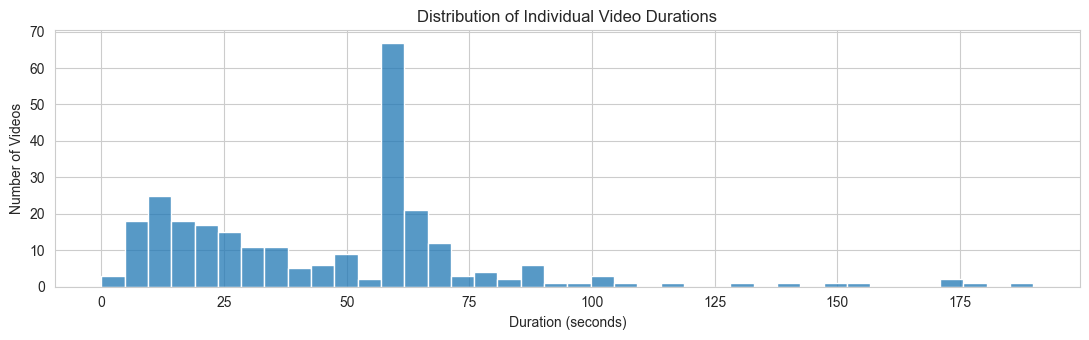

In [78]:
# Distribution of individual video durations.
fig, ax = plt.subplots(figsize=(11, 3.5))
sns.histplot(data=videos, x="video_duration", bins=40, ax=ax)
ax.set_title("Distribution of Individual Video Durations")
ax.set_xlabel("Duration (seconds)")
ax.set_ylabel("Number of Videos")
plt.tight_layout()
plt.show()


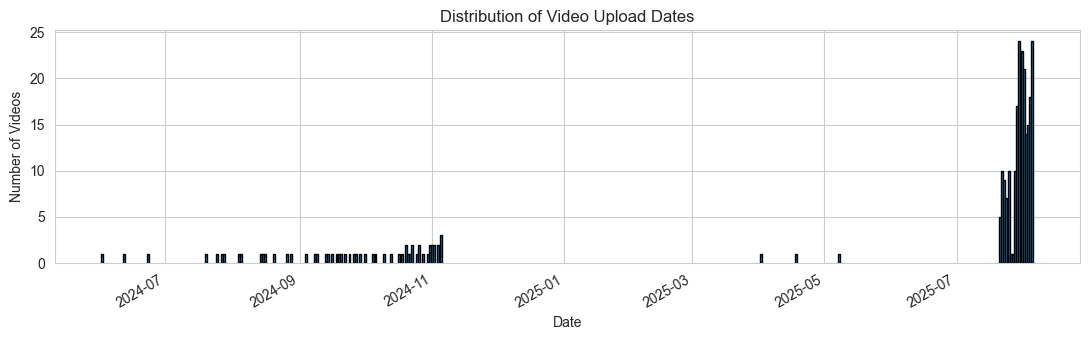

In [79]:
# Distribution of upload dates (one bar per day).
fig, ax = plt.subplots(figsize=(11, 3.5))
videos["video_date"] = videos["video_timestamp"].dt.date
date_counts = videos["video_date"].value_counts().sort_index()
ax.bar(date_counts.index, date_counts.values, edgecolor="black", width=0.9)
ax.set_title("Distribution of Video Upload Dates")
ax.set_xlabel("Date")
ax.set_ylabel("Number of Videos")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


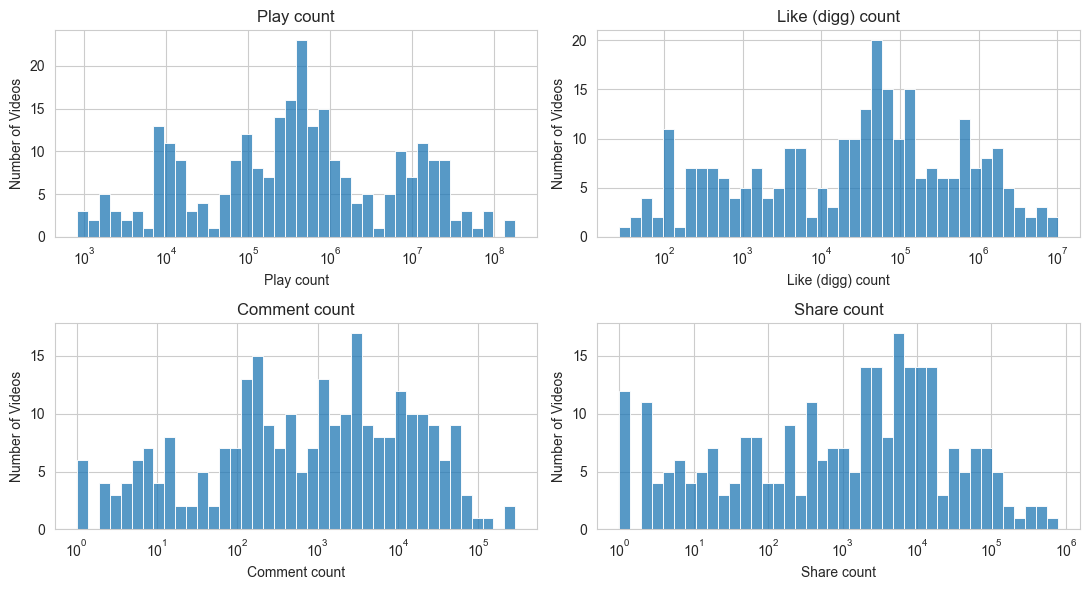

In [80]:
# Engagement distributions (log scale — play counts span several orders of magnitude).
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
metrics = [("video_playcount",    "Play count"),
           ("video_diggcount",    "Like (digg) count"),
           ("video_commentcount", "Comment count"),
           ("video_sharecount",   "Share count")]
for ax, (col, label) in zip(axes.flat, metrics):
    sns.histplot(videos[col].clip(lower=1), bins=40, log_scale=True, ax=ax)
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel("Number of Videos")
plt.tight_layout()
plt.show()


### 3.3 Per-user aggregates

In [81]:
# Build a per-user summary: video count, total duration, total plays.
per_user = (
    videos.groupby("author_username")
          .agg(video_count        = ("video_id",         "count"),
               total_duration_min = ("video_duration",   lambda s: s.sum() / 60.0),
               total_plays        = ("video_playcount",  "sum"),
               total_likes        = ("video_diggcount",  "sum"))
          .sort_values("video_count", ascending=False)
)
per_user.round(1)


,video_count,total_duration_min,total_plays,total_likes
author_username,,,,
aaronparnas1,73,78.6,59147600,6297632
netflix,70,55.4,102417143,6335196
apnews,69,59.4,6013972,327543
realdonaldtrump,58,17.4,1545500000,109515100


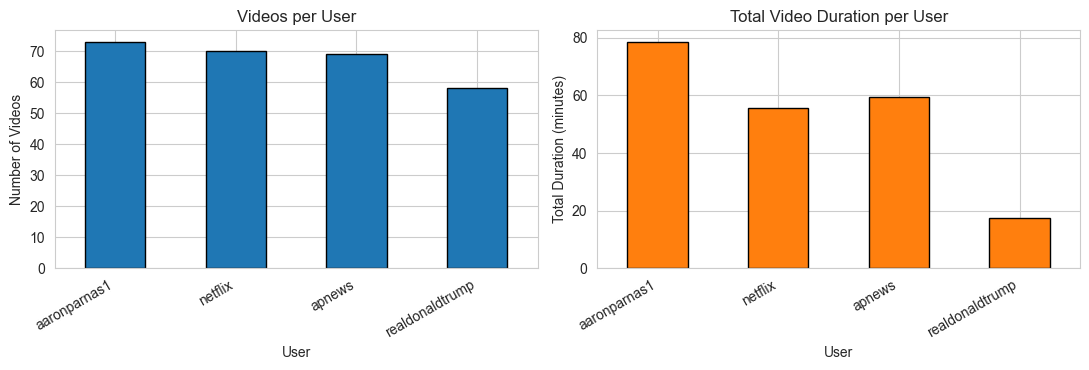

In [82]:
# Distribution of videos per user.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

per_user["video_count"].plot(kind="bar", ax=axes[0], edgecolor="black")
axes[0].set_title("Videos per User")
axes[0].set_xlabel("User")
axes[0].set_ylabel("Number of Videos")

per_user["total_duration_min"].plot(kind="bar", ax=axes[1], edgecolor="black", color="C1")
axes[1].set_title("Total Video Duration per User")
axes[1].set_xlabel("User")
axes[1].set_ylabel("Total Duration (minutes)")

for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()


### 3.4 Comments analysis

Comment files use a different schema from video files — wider (29-30 cols),
with text, language, reply counts, and a `user` field stored as a
Python-literal string blob. The cells below load every comment CSV in
`sample_data/`, normalise the user blob, and ask a few simple questions:

- How many comments did each video draw?
- How long are the comments?
- What languages show up?
- Who comments the most across the sample?
- How often do comments draw replies?


In [83]:
def _parse_user_blob(blob):
    """The `user` column is a Python literal dict-as-string. Pull the few
    fields we actually need (nickname + unique_id) and shrug off anything
    that fails to parse."""
    if not isinstance(blob, str) or not blob.startswith("{"):
        return None, None
    try:
        d = ast.literal_eval(blob)
    except Exception:
        return None, None
    return d.get("nickname"), d.get("unique_id")

comments_frames = []
for p in comment_files:
    df = pd.read_csv(p)
    # The video the comments were collected from = aweme_id (TikTok's internal name).
    df["video_id"] = df["aweme_id"].astype(str)
    df["source_file"] = p.name
    comments_frames.append(df)

comments = pd.concat(comments_frames, ignore_index=True)

# Drop duplicate rows that show up when sample_data contains a *copy* of the
# same CSV (or you accidentally glob the same file twice). cid is the
# TikTok-side primary key for a comment.
before = len(comments)
comments = comments.drop_duplicates(subset=["cid"])
dropped = before - len(comments)
if dropped:
    print(f"  (de-duplicated {dropped:,} repeated comment rows)")

# Normalise the user blob into two columns.
comments[["user_nickname", "user_unique_id"]] = comments["user"].apply(
    lambda b: pd.Series(_parse_user_blob(b))
)

# Useful derived columns.
comments["create_time"] = pd.to_datetime(comments["create_time"], unit="s", errors="coerce")
comments["text_length"] = comments["text"].fillna("").str.len()

print(f"Comments loaded : {len(comments):,}")
print(f"Unique videos   : {comments['video_id'].nunique()}")
print(f"Unique users    : {comments['user_unique_id'].nunique():,}")
print(f"Date range      : {comments['create_time'].min()} -> {comments['create_time'].max()}")


  (de-duplicated 968 repeated comment rows)
Comments loaded : 5,874
Unique videos   : 7
Unique users    : 5,511
Date range      : 2025-07-26 11:07:50 -> 2025-08-07 01:41:13


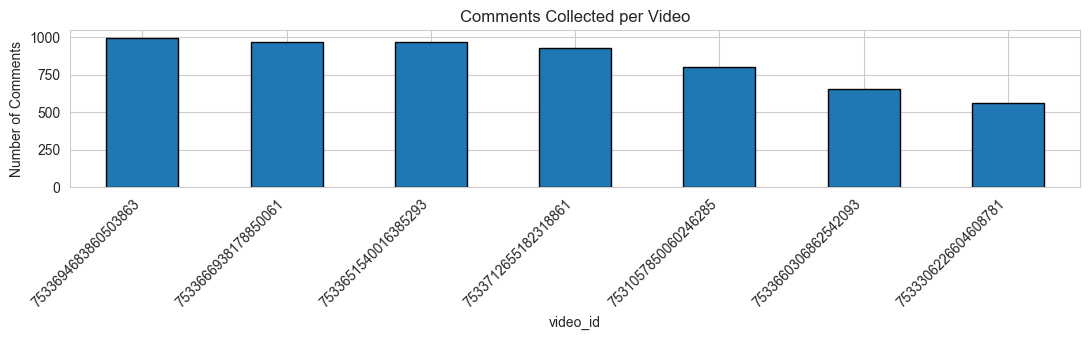

video_id
7533694683860503863    995
7533666938178850061    968
7533651540016385293    967
7533712655182318861    927
7531057850060246285    802
7533660306862542093    653
7533306226604608781    562
dtype: int64

In [84]:
# How many comments per video.
per_video = comments.groupby("video_id").size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 3.5))
per_video.plot(kind="bar", ax=ax, edgecolor="black")
ax.set_title("Comments Collected per Video")
ax.set_xlabel("video_id")
ax.set_ylabel("Number of Comments")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

per_video.head(10)


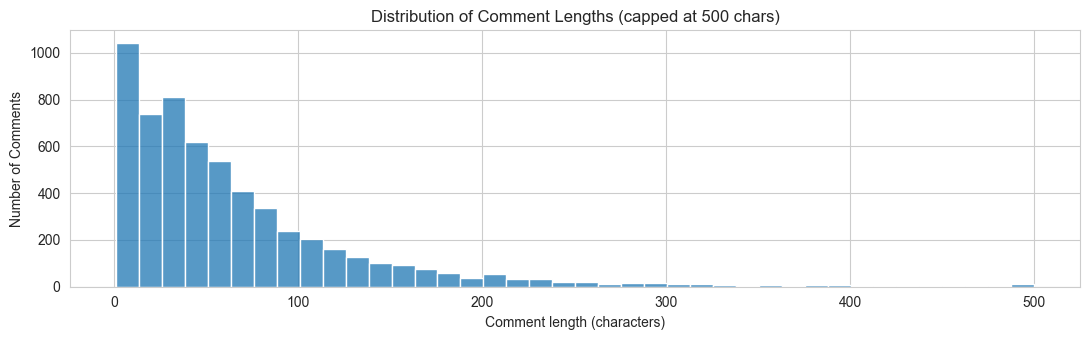

Median length : 45
Mean length   : 65.7
Longest       : 2199


In [85]:
# Comment length distribution (characters).
fig, ax = plt.subplots(figsize=(11, 3.5))
sns.histplot(comments["text_length"].clip(upper=500), bins=40, ax=ax)
ax.set_title("Distribution of Comment Lengths (capped at 500 chars)")
ax.set_xlabel("Comment length (characters)")
ax.set_ylabel("Number of Comments")
plt.tight_layout()
plt.show()

print("Median length :", int(comments["text_length"].median()))
print("Mean length   :", round(comments["text_length"].mean(), 1))
print("Longest       :", int(comments["text_length"].max()))


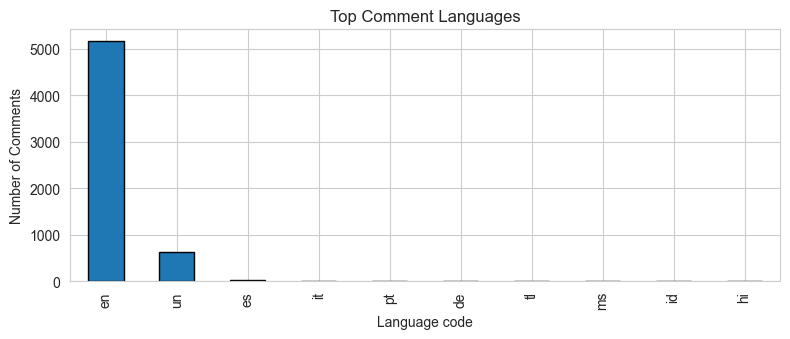

comment_language
en    5157
un     635
es      20
it      11
pt       8
de       7
tl       6
ms       6
id       6
hi       3
Name: count, dtype: int64

In [86]:
# Top languages.
lang_counts = comments["comment_language"].value_counts().head(10)
fig, ax = plt.subplots(figsize=(8, 3.5))
lang_counts.plot(kind="bar", ax=ax, edgecolor="black")
ax.set_title("Top Comment Languages")
ax.set_xlabel("Language code")
ax.set_ylabel("Number of Comments")
plt.tight_layout()
plt.show()
lang_counts


In [87]:
# Top commenters across the whole sample.
# CHANGE TOP_N TO SEE MORE OR FEWER COMMENTERS
TOP_N = 15

top_commenters = (
    comments.dropna(subset=["user_unique_id"])
            .groupby(["user_unique_id", "user_nickname"])
            .agg(comments     = ("cid",          "count"),
                 total_likes  = ("digg_count",   "sum"),
                 avg_length   = ("text_length",  "mean"))
            .sort_values("comments", ascending=False)
            .head(TOP_N)
)
top_commenters.round(1)


,,comments,total_likes,avg_length
user_unique_id,user_nickname,,,
badw0lf12,Badw0lf12,5,26,66.2
johnnymaxrain,johnny rainbolt,4,1406,57.0
hollyblake3,hollyblake3,4,1,1.5
texascookee,texascookee,4,1064,94.5
laurenhouli,like if you love jueus,4,31,28.2
angiecornejo90,Angie,4,2,39.8
ls4279,user9907101721782,3,3,77.3
wellblessyoursweetheart,Lucille Made Me Say It,3,1,1.0
artlover4me,artlover4me,3,1,98.3


Total comments       : 5,874
With at least 1 reply: 423  (7.2%)
Mean replies/comment : 0.42
Max replies/comment  : 191


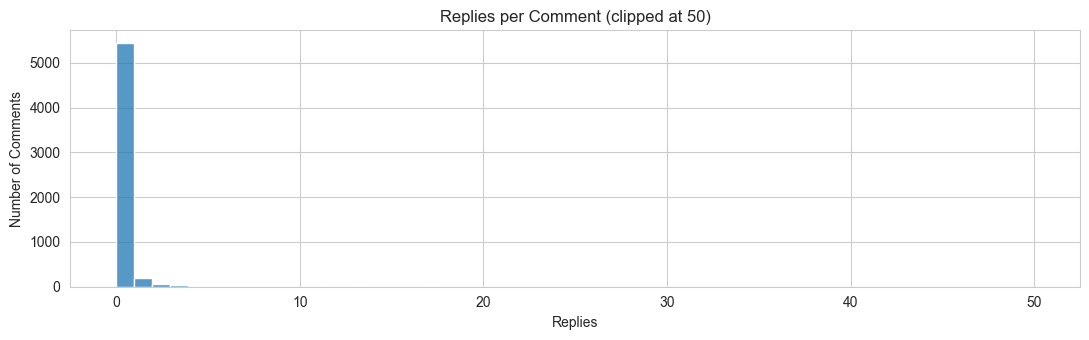

In [88]:
# Reply patterns: how many comments draw at least one reply?
total          = len(comments)
with_replies   = (comments["reply_comment_total"].fillna(0) > 0).sum()
share_with_rep = 100 * with_replies / total if total else 0.0

print(f"Total comments       : {total:,}")
print(f"With at least 1 reply: {with_replies:,}  ({share_with_rep:.1f}%)")
print(f"Mean replies/comment : {comments['reply_comment_total'].fillna(0).mean():.2f}")
print(f"Max replies/comment  : {int(comments['reply_comment_total'].fillna(0).max())}")

# Distribution of reply counts (clipped at 50 so the bulk is visible).
fig, ax = plt.subplots(figsize=(11, 3.5))
sns.histplot(comments["reply_comment_total"].fillna(0).clip(upper=50),
             bins=51, ax=ax)
ax.set_title("Replies per Comment (clipped at 50)")
ax.set_xlabel("Replies")
ax.set_ylabel("Number of Comments")
plt.tight_layout()
plt.show()
